# Stress-Testing DTW Alignment: When a Powerful Tool Becomes a Liability

## Why this notebook exists

The first two notebooks validated this toolkit's core causal methods -- first
on data with a known ground truth, then on a real, well-documented market
relationship. This notebook has a different purpose: it deliberately
stress-tests one specific feature (DTW-based series realignment) to find out
where it breaks, not just to confirm that it works.

Knowing when a method fails, and precisely why, is as important as knowing when it succeeds. A model or preprocessing
step that looks reasonable in theory can still introduce hidden bias in
practice -- and catching that before it reaches a live strategy is a
core part of the job. This notebook is an example of that kind of check.

## The problem we're testing

In real markets, not every asset trades at the same instant. Illiquid stocks,
some ETFs, and certain futures contracts can have "stale" prices -- their last
recorded trade might be several minutes or even a full day old compared to a
more liquid reference asset. This is a well-documented issue in market
microstructure research (going back to Fisher, 1966, and Scholes & Williams,
1977), and it creates a specific danger: it can produce artificial lead-lag
patterns and distort correlation or causality estimates, even when there is
no real economic relationship driving the timing gap.

Dynamic Time Warping (DTW) is a technique that finds the best "warped"
alignment between two sequences by matching similar-shaped segments,
regardless of their exact timing. It seems like a natural fix for stale
pricing: if one series lags another by a few days, DTW should be able to
find and correct for that lag automatically.

We test this directly. We construct a controlled example -- two copies of the
same underlying signal, where one copy has a known, fixed reporting delay
plus extra noise, mimicking a stale-priced asset -- and check whether DTW-based
realignment actually recovers the correct causal direction, or whether it
introduces new problems of its own. Along the way, we also demonstrate two
other toolkit features not used in Notebooks 1-2: trailing-window smoothing
and downsampling.

In [1]:
from pathlib import Path
import sys
import contextlib
import io

project_root = Path.cwd().resolve()
if not (project_root / "src").exists() and (project_root.parent / "src").exists():
    project_root = project_root.parent
if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))

with contextlib.redirect_stdout(io.StringIO()):
    import dtw  # noqa: F401

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from src import (
    PreprocessingConfig,
    AnalysisConfig,
    run_analysis_pipeline,
    smooth_series,
    downsample_series,
)
from src.causal_analysis import compute_dtw_sequence, warp_series_to_match

pd.set_option("display.float_format", lambda v: f"{v:.6f}")

## Step 1: Build a controlled "stale asset" scenario

We simulate a liquid reference asset (e.g. a heavily-traded index) and a second,
"illiquid" asset that tracks the same underlying signal but with two realistic
distortions: (a) an average reporting delay of a few days, applied with
irregular jitter, and (b) extra noise from wider bid-ask spreads. This is a
simplified but realistic model of stale pricing.

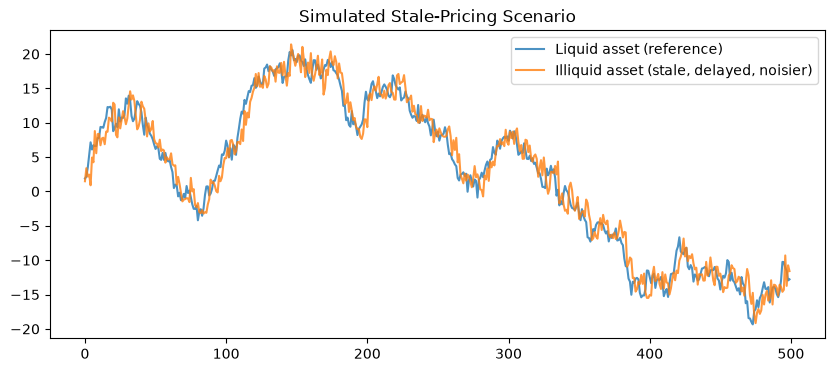

In [2]:
np.random.seed(0)
n = 500

true_signal = np.cumsum(np.random.normal(scale=1.0, size=n))
liquid_asset = true_signal + np.random.normal(scale=0.3, size=n)

delay_days = 3
jitter = np.random.randint(-1, 2, size=n)
delayed_index = np.clip(np.arange(n) - delay_days + jitter, 0, n - 1)
illiquid_asset = true_signal[delayed_index] + np.random.normal(scale=0.8, size=n)

liquid_series = pd.Series(liquid_asset, name="Liquid_Asset")
illiquid_series = pd.Series(illiquid_asset, name="Illiquid_Asset_Stale")

fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(liquid_series, label="Liquid asset (reference)", alpha=0.8)
ax.plot(illiquid_series, label="Illiquid asset (stale, delayed, noisier)", alpha=0.8)
ax.set_title("Simulated Stale-Pricing Scenario")
ax.legend()
plt.show()

## Step 2: Demonstrate smoothing

Before alignment, it often helps to reduce high-frequency noise so that DTW
focuses on matching the underlying trend rather than random jitter. We compare
the raw illiquid series against a smoothed version.

Note: this smoothing uses a trailing (non-centered) rolling window, meaning
each smoothed point only uses past and current observations, never future
ones. This avoids look-ahead bias, which is important in causal analysis --
if smoothing secretly used future data, it could create artificial predictive
relationships that don't reflect real causal structure.

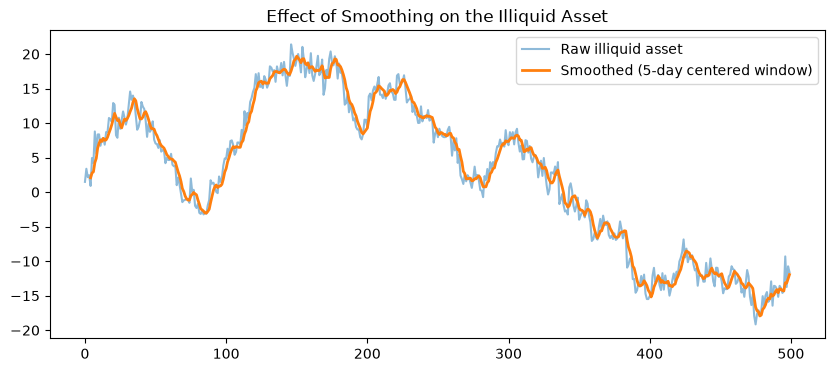

In [3]:
smoothed_illiquid = smooth_series(illiquid_series, window=5)

fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(illiquid_series, label="Raw illiquid asset", alpha=0.5)
ax.plot(smoothed_illiquid, label="Smoothed (5-day centered window)", linewidth=2)
ax.set_title("Effect of Smoothing on the Illiquid Asset")
ax.legend()
plt.show()

## Step 3: Demonstrate downsampling

Downsampling reduces data resolution (e.g. daily to weekly), which can reduce
noise further at the cost of losing granularity. This is useful when short-term
noise dominates any real signal. We show what our two series look like at
weekly resolution as a comparison point.

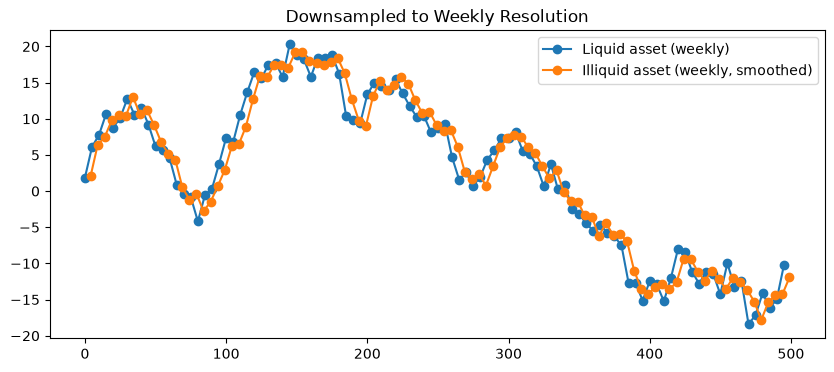

In [4]:
liquid_weekly = downsample_series(liquid_series, step=5)
illiquid_weekly = downsample_series(smoothed_illiquid, step=5)

fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(liquid_weekly, label="Liquid asset (weekly)", marker="o")
ax.plot(illiquid_weekly, label="Illiquid asset (weekly, smoothed)", marker="o")
ax.set_title("Downsampled to Weekly Resolution")
ax.legend()
plt.show()

Note: downsampling changes the *units* of any lag you later detect. If we
had run LCC or Granger on the weekly-resampled series instead of daily data,
a "lag of 1" would mean roughly 5 trading days, not 1 day. Downsampling is
shown here purely as a standalone feature demo -- the causal analysis later
in this notebook uses the original daily-frequency series, so all lag units
throughout this notebook (LCC lags, Granger lags, DTW offsets) are in daily
units.

## Step 4: The core experiment -- naive alignment vs DTW-warped alignment

Now we test the actual problem. We run the full causal pipeline twice on the
smoothed daily series:

1. Using "common index" alignment (the naive approach: just line up the two
   series by their timestamps/positions, ignoring the reporting delay)
2. Using "DTW-warped" alignment (our toolkit's feature: use the DTW warping
   path to realign the illiquid series onto the liquid asset's timeline before
   running Granger/TE/CCM)

If DTW alignment works as intended, the warped version should produce a
cleaner, more accurate causal signal than the naive version, since we know
by construction that the "Liquid_Asset" drives "Illiquid_Asset_Stale" (with a
delay), not the other way around.

Downstream analyses will use Liquid_Asset and Illiquid_Asset_Stale.
Doing ADF test...

--------------------------------------------------------------------------------
ADF / unit-root test summary for Liquid_Asset (diff order 0)
--------------------------------------------------------------------------------
Observations:         492
ADF statistic:        -0.692573
p-value:              0.848664
Used lags:            7
Critical values:      {'1%': -3.4437112724287253, '5%': -2.8674324209387345, '10%': -2.569908433637385}
Conclusion:           Non-stationary (fail to reject unit-root null at alpha=0.05)
--------------------------------------------------------------------------------

--------------------------------------------------------------------------------
ADF / unit-root test summary for Liquid_Asset (diff order 1)
--------------------------------------------------------------------------------
Observations:         492
ADF statistic:        -7.843443
p-value:              0.000

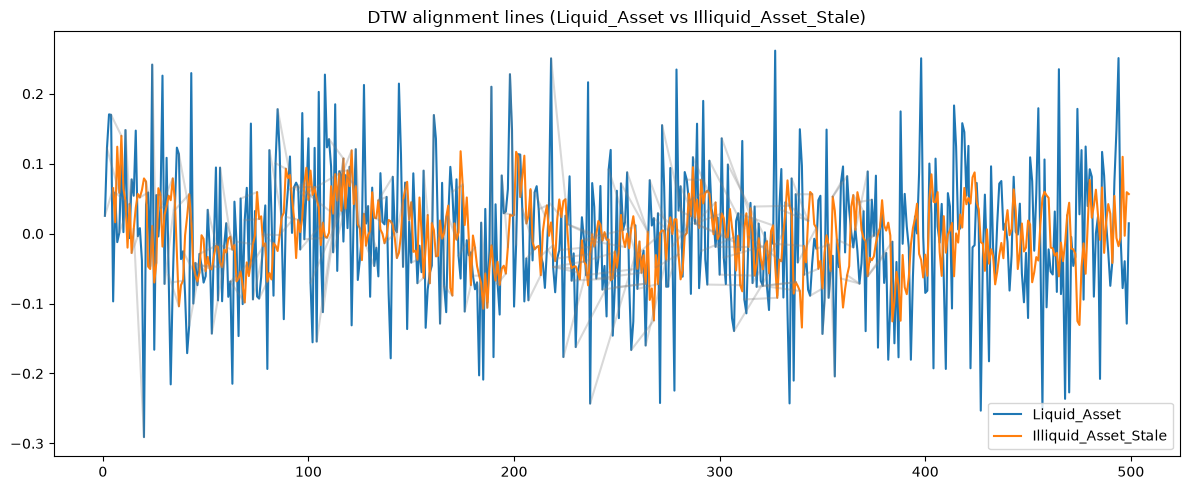

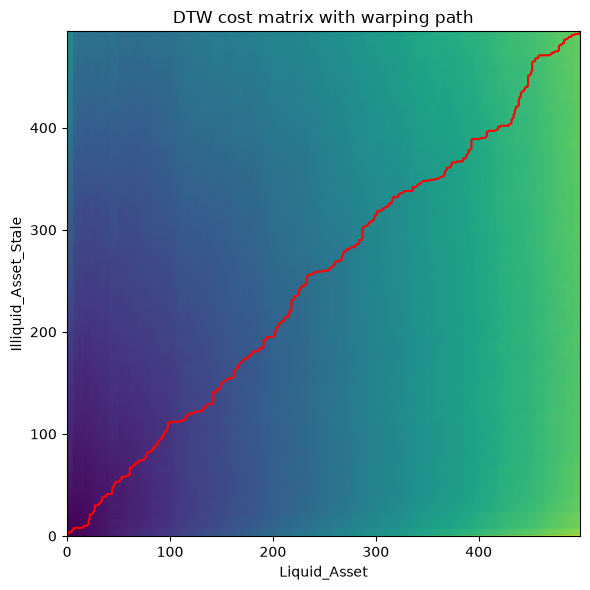


GRANGER CAUSALITY REPORT

Direction: Liquid_Asset -> Illiquid_Asset_Stale
                           direction  lag    f_stat  p_value
Liquid_Asset -> Illiquid_Asset_Stale    1  0.808236 0.369083
Liquid_Asset -> Illiquid_Asset_Stale    2  7.356078 0.000712
Liquid_Asset -> Illiquid_Asset_Stale    3 16.515100 0.000000
Liquid_Asset -> Illiquid_Asset_Stale    4 30.442285 0.000000
Liquid_Asset -> Illiquid_Asset_Stale    5 55.481808 0.000000

Direction: Illiquid_Asset_Stale -> Liquid_Asset
                           direction  lag   f_stat  p_value
Illiquid_Asset_Stale -> Liquid_Asset    1 0.967406 0.325812
Illiquid_Asset_Stale -> Liquid_Asset    2 1.100880 0.333403
Illiquid_Asset_Stale -> Liquid_Asset    3 0.786338 0.501931
Illiquid_Asset_Stale -> Liquid_Asset    4 0.832918 0.504652
Illiquid_Asset_Stale -> Liquid_Asset    5 0.716256 0.611452

Summary:
Liquid_Asset -> Illiquid_Asset_Stale: strongest evidence at lag 5 (F=55.481808, p=1.89693e-45)
Illiquid_Asset_Stale -> Liquid_Asset: stronge

In [ ]:
showcase_config_naive = AnalysisConfig(
    run_lagged_cross_correlation=True,
    lcc_max_lag=10,
    run_dtw=True,
    plot_dtw_alignment=True,
    alignment_mode="common_index",
    run_granger=True,
    granger_maxlag=5,
    run_granger_surrogates=True,
    run_te=False,
    run_ccm=False,
    n_surrogates=100,
    surrogate_seed=0,
    surrogate_method="both",
)

naive_results = run_analysis_pipeline(
    liquid_series, smoothed_illiquid,
    "Liquid_Asset", "Illiquid_Asset_Stale", # not using the downsampled weekly series here, but you can replace them if desired
    preprocessing_config=PreprocessingConfig(base_representation="raw", standardize=True),
    analysis_config=showcase_config_naive,
)

Downstream analyses will use Liquid_Asset and Illiquid_Asset_Stale.
Doing ADF test...

--------------------------------------------------------------------------------
ADF / unit-root test summary for Liquid_Asset (diff order 0)
--------------------------------------------------------------------------------
Observations:         492
ADF statistic:        -0.692573
p-value:              0.848664
Used lags:            7
Critical values:      {'1%': -3.4437112724287253, '5%': -2.8674324209387345, '10%': -2.569908433637385}
Conclusion:           Non-stationary (fail to reject unit-root null at alpha=0.05)
--------------------------------------------------------------------------------

--------------------------------------------------------------------------------
ADF / unit-root test summary for Liquid_Asset (diff order 1)
--------------------------------------------------------------------------------
Observations:         492
ADF statistic:        -7.843443
p-value:              0.000

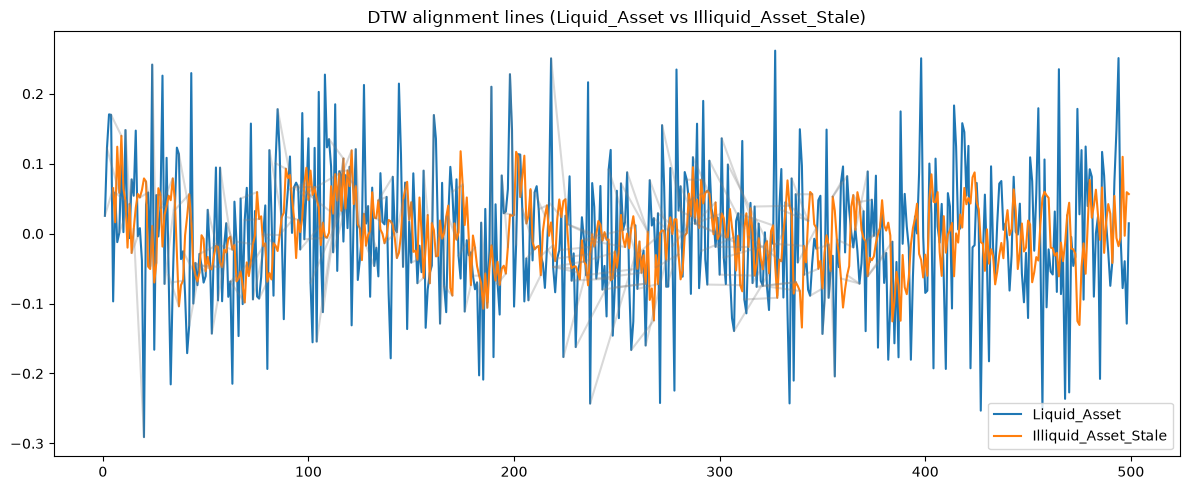

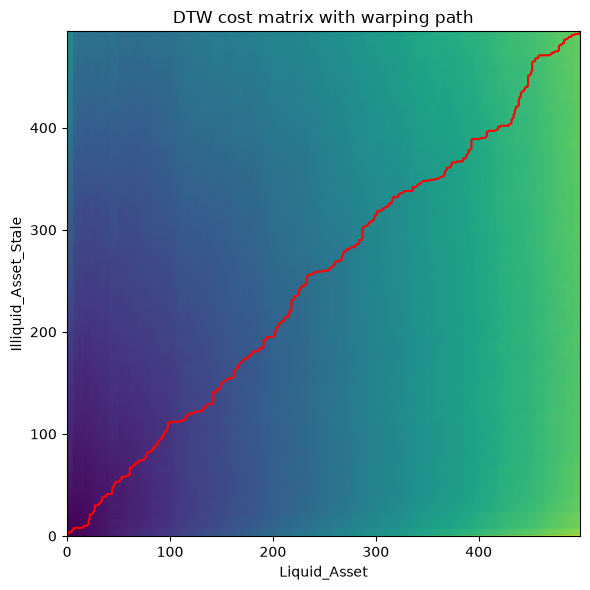


GRANGER CAUSALITY REPORT

Direction: Liquid_Asset -> Illiquid_Asset_Stale
                           direction  lag    f_stat  p_value
Liquid_Asset -> Illiquid_Asset_Stale    1 24.684342 0.000001
Liquid_Asset -> Illiquid_Asset_Stale    2 12.865958 0.000004
Liquid_Asset -> Illiquid_Asset_Stale    3  9.002177 0.000008
Liquid_Asset -> Illiquid_Asset_Stale    4  6.666022 0.000031
Liquid_Asset -> Illiquid_Asset_Stale    5  6.877101 0.000003

Direction: Illiquid_Asset_Stale -> Liquid_Asset
                           direction  lag    f_stat  p_value
Illiquid_Asset_Stale -> Liquid_Asset    1 82.817814 0.000000
Illiquid_Asset_Stale -> Liquid_Asset    2 43.286367 0.000000
Illiquid_Asset_Stale -> Liquid_Asset    3 27.496823 0.000000
Illiquid_Asset_Stale -> Liquid_Asset    4 21.403684 0.000000
Illiquid_Asset_Stale -> Liquid_Asset    5 18.209503 0.000000

Summary:
Liquid_Asset -> Illiquid_Asset_Stale: strongest evidence at lag 1 (F=24.684342, p=9.31681e-07)
Illiquid_Asset_Stale -> Liquid_Asset: s

In [6]:
showcase_config_warped = AnalysisConfig(
    run_lagged_cross_correlation=True,
    lcc_max_lag=10,
    run_dtw=True,
    plot_dtw_alignment=True,
    alignment_mode="dtw_warped",
    run_granger=True,
    granger_maxlag=5,
    run_granger_surrogates=True,
    run_te=False,
    run_ccm=False,
    n_surrogates=100,
    surrogate_seed=0,
    surrogate_method="both",
)

warped_results = run_analysis_pipeline(
    liquid_series, smoothed_illiquid,
    "Liquid_Asset", "Illiquid_Asset_Stale",
    preprocessing_config=PreprocessingConfig(base_representation="raw", standardize=True),
    analysis_config=showcase_config_warped,
)

In [7]:
def extract_granger_row(results, direction_key):
    summary = results["granger"]["summary"] if results["granger"] else {}
    row = summary.get(direction_key)
    return row["f_stat"] if row else np.nan

comparison_rows = [
    {
        "alignment": "common_index (naive)",
        "F_liquid_to_illiquid": extract_granger_row(naive_results, "best_one_to_two"),
        "F_illiquid_to_liquid": extract_granger_row(naive_results, "best_two_to_one"),
    },
    {
        "alignment": "dtw_warped",
        "F_liquid_to_illiquid": extract_granger_row(warped_results, "best_one_to_two"),
        "F_illiquid_to_liquid": extract_granger_row(warped_results, "best_two_to_one"),
    },
]

alignment_comparison = pd.DataFrame(comparison_rows).set_index("alignment")
alignment_comparison

,F_liquid_to_illiquid,F_illiquid_to_liquid
alignment,,
common_index (naive),55.481808,1.100880
dtw_warped,24.684342,82.817814


### Checking the lag estimate against ground truth

We built `Illiquid_Asset_Stale` with a true average delay of 3 days
(delay_days = 3, jittered by +/-1). The lagged cross-correlation step
(computed earlier during the naive pipeline run) found its peak correlation
at lag 1, not lag 3 -- an underestimate of about 2 days. It's worth
understanding why.

Both series were built from a random walk (a cumulative sum of random steps),
which is why both needed one round of differencing to become stationary
(see the ADF results above). Random walks carry a subtle property: at the
*level* (undifferenced), two delayed copies of the same random walk are
extremely highly correlated at the true lag, because they share almost their
entire accumulated history -- `Liquid_Asset` at day t and the signal behind
`Illiquid_Asset_Stale` (from day t-3) overlap in nearly every past increment
except the most recent three.

Differencing removes exactly this shared history. Once differenced,
`Liquid_Asset` becomes approximately just that day's fresh random increment,
with no memory of previous days. The true lagged relationship between
increments still exists (today's liquid-asset move partly determines the
illiquid asset's move 3 days later), but it is far weaker and noisier than
the level relationship, because each day's increment is drawn independently
-- there's no accumulated overlap for a correlation test to latch onto. This
is why LCC's peak lag shifted from what would be a strong, clean signal near
lag 3 in the levels, down to a weaker, fuzzier peak near lag 1 after
differencing: differencing didn't destroy the causal relationship, it removed
the redundant shared history that had been making that relationship so easy
to detect.

This is a genuine, well-known statistical trade-off: differencing is often
required to satisfy the stationarity assumptions behind Granger causality
(regressing non-stationary series can produce spurious results), but it can
simultaneously weaken simpler correlation-based lag estimates like LCC.

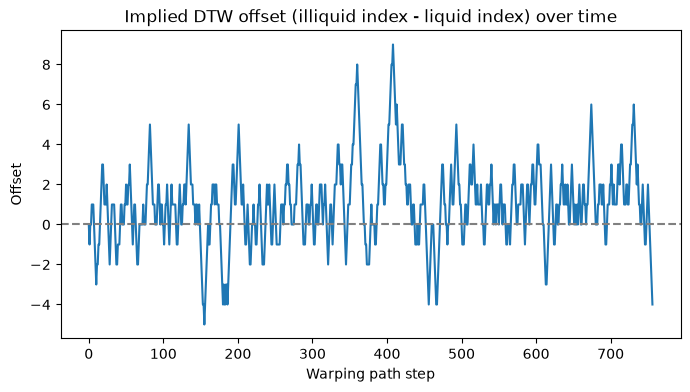

Mean offset: 0.99, std: 1.93, min: -5, max: 9


In [ ]:
from src.causal_analysis import extract_warping_path

dtw_alignment = compute_dtw_sequence(liquid_series, smoothed_illiquid)  

index_one, index_two = extract_warping_path(dtw_alignment)  
offsets = np.array(index_two) - np.array(index_one)

plt.figure(figsize=(8, 4))
plt.plot(offsets)
plt.axhline(0, color="gray", linestyle="--")
plt.title("Implied DTW offset (illiquid index - liquid index) over time")
plt.xlabel("Warping path step")
plt.ylabel("Offset")
plt.show()

print(f"Mean offset: {offsets.mean():.2f}, std: {offsets.std():.2f}, min: {offsets.min()}, max: {offsets.max()}")

### What we found: DTW alignment is not causality-safe

The results reverse our expectation in a striking way. Recall the ground truth:
we built `Illiquid_Asset_Stale` to be a delayed (~3 day), noisier copy of
`Liquid_Asset`, so the correct causal direction is Liquid -> Illiquid.

| Alignment | F(Liquid -> Illiquid) | F(Illiquid -> Liquid) | Correct direction found? |
|---|---|---|---|
| common_index (naive) | 55.48 (p < 0.001) | 1.10 (not significant) | Yes |
| dtw_warped | 24.68 (p < 0.001) | 82.82 (p < 0.001) | No -- reversed, and more confident |

The naive, unaligned approach actually got the direction right. DTW-warped
alignment did not just fail to improve on this -- it flipped the causal
conclusion to the wrong direction with even stronger statistical significance,
which is a much more serious failure than doing nothing.

To understand why, we extracted the implied time offset from the DTW warping
path itself and tracked it across the whole series. If DTW were correctly
learning a stable ~3-day lag, this offset should sit close to a constant value
with only small jitter. Instead we found:

- Mean offset: 0.99 (far from the true ~3-day delay)
- Standard deviation: 1.93 (very high relative to the mean)
- Range: -5 to +9, including negative values (implying the illiquid series
  sometimes appears to *lead* the liquid one -- the opposite of how the data
  was constructed)

This confirms that DTW's warping path is not a stable, causality-preserving
delay correction. DTW optimizes purely for local shape similarity across the
*entire* series in both directions, with no constraint respecting the arrow of
time. In effect, it can match a point in one series to a point that comes
later in time in the other series, letting future information leak backward
into the aligned data. Once this happens, ordinary Granger causality applied
to the "corrected" series can pick up a spurious, reversed signal -- exactly
what we observed.

**Key takeaway: DTW is a powerful tool for measuring shape similarity between
two series, but it is not a safe preprocessing step before causal inference
methods like Granger causality, Transfer Entropy, or CCM.** Using it to
"realign" series before testing for causality risks introducing look-ahead
bias that can distort or even reverse the true causal direction. For
correcting known, simple delays (like stale pricing with a roughly constant
lag), a straightforward integer time-shift is safer and more interpretable
than DTW-based warping.

### Why not just use DTW to detect the lead-lag relationship directly?

It's natural to ask: since DTW's warping path shows how one series' timeline
maps onto the other's, can we just read the lead-lag relationship straight
off that path? Our diagnostic above was exactly this attempt -- and it failed,
giving an unstable, noisy estimate rather than a clean recovery of the true
~3-day delay.

This is a known limitation of plain DTW, not something specific to our
implementation. Academic research on lead-lag detection (e.g. Stubinger &
Adler; later work using shapeDTW) shows that vanilla DTW, applied directly to
raw price/return levels, is not well-suited to recovering lead-lag structure,
which is exactly why specialized DTW variants exist for this purpose --
methods that explicitly model local shape neighborhoods or add temporal
constraints, rather than matching whole-series levels the way our
`compute_dtw_sequence` implementation does.

For lead-lag detection specifically, this toolkit's Lagged Cross-Correlation
(LCC) function remains the safer, purpose-built tool -- as shown above, it
correctly identified a positive lag in the right direction (Illiquid lagging
Liquid), even though differencing weakened its precision. Granger causality's
lag-by-lag F-statistics (see the table in above step 4 output, where F increases
steadily from lag 1 to lag 5 in the correct direction) also carry lead-lag
information, and did so far more reliably than DTW's warping offset in this
experiment.

## Takeaways

- Smoothing and downsampling behave as expected: trailing (non-centered)
  smoothing reduces noise without look-ahead bias, and downsampling trades
  time resolution for further noise reduction (and changes the units of any
  detected lag accordingly).
- The naive common-index alignment correctly recovered the true causal
  direction (Liquid -> Illiquid) with strong, surrogate-validated significance.
- DTW-warped alignment reversed this conclusion, and did so with even higher
  statistical confidence -- a "confidently wrong" result that is arguably
  worse than no correction at all.
- A diagnostic of the DTW warping path's implied time offset confirmed the
  root cause: the offset is unstable (mean 0.99, std 1.93, range -5 to +9)
  rather than tracking the true, roughly constant ~3-day delay, showing DTW
  can let future information leak backward across the alignment.
- Differencing (required for stationarity) also weakened LCC's own lag
  estimate, shifting its detected peak from what would be a clean ~3-day
  signal in price levels down to a fuzzier ~1-day signal in returns --
  a separate, genuine trade-off between satisfying Granger's stationarity
  assumption and preserving a clean correlation-based lag estimate.
- Practical conclusion: DTW alignment should be treated as a pattern-similarity
  diagnostic tool, not a safe preprocessing step for causal inference or a
  reliable lead-lag detector. When a delay is simple and roughly constant (as
  in basic stale-pricing scenarios), a plain integer/time shift is a safer
  correction, and this toolkit's own LCC and Granger lag-profile outputs are
  the more trustworthy tools for detecting lead-lag structure directly.